# About the Data

This data was obtained from [Kaggle](https://www.kaggle.com/datasets/dansbecker/melbourne-housing-snapshot) and can be downloaded after going through the link.
It was scraped from publicly available results posted every week from Domain.com.au. He cleaned it well, and now it's up to you to make data analysis magic. The dataset includes Address, Type of Real estate, Suburb, Method of Selling, Rooms, Price, Real Estate Agent, Date of Sale and distance from C.B.D.

## Notes on Specific Variables
Rooms: Number of rooms

Price: Price in dollars

Method: S - property sold; SP - property sold prior; PI - property passed in; PN - sold prior not disclosed; SN - sold not disclosed; NB - no bid; VB - vendor bid; W - withdrawn prior to auction; SA - sold after auction; SS - sold after auction price not disclosed. N/A - price or highest bid not available.

Type: br - bedroom(s); h - house,cottage,villa, semi,terrace; u - unit, duplex; t - townhouse; dev site - development site; o res - other residential.

SellerG: Real Estate Agent

Date: Date sold

Distance: Distance from CBD

Regionname: General Region (West, North West, North, North east …etc)

Propertycount: Number of properties that exist in the suburb.

Bedroom2 : Scraped # of Bedrooms (from different source)

Bathroom: Number of Bathrooms

Car: Number of carspots

Landsize: Land Size

BuildingArea: Building Size

CouncilArea: Governing council for the area

# Questions asked
1. What does the price trend look like?
2. What types are cheap and which ones are expensive?
3. Suburbs with the lowest price and max rooms.
4. How distance from central distrcit affect price?

In [139]:
# importing libraries
import numpy as np
import polars as pl # using polars as a replacement to pandas
import matplotlib.pyplot as plt
import seaborn as sns

In [140]:
# Setting style for plots
sns.set_theme(context='notebook', style='whitegrid', palette='muted', font_scale=1.1)

In [141]:
path = '../../kaggle_datasets/05_melborune_houses/melb_data.csv'
df = pl.read_csv(path)

# **EDA**

In [142]:
type_map = {
    'h': 'House',
    't': 'Townhouse',
    'u': 'Unit'
}

df = df.with_columns(pl.col("Type").replace(type_map))

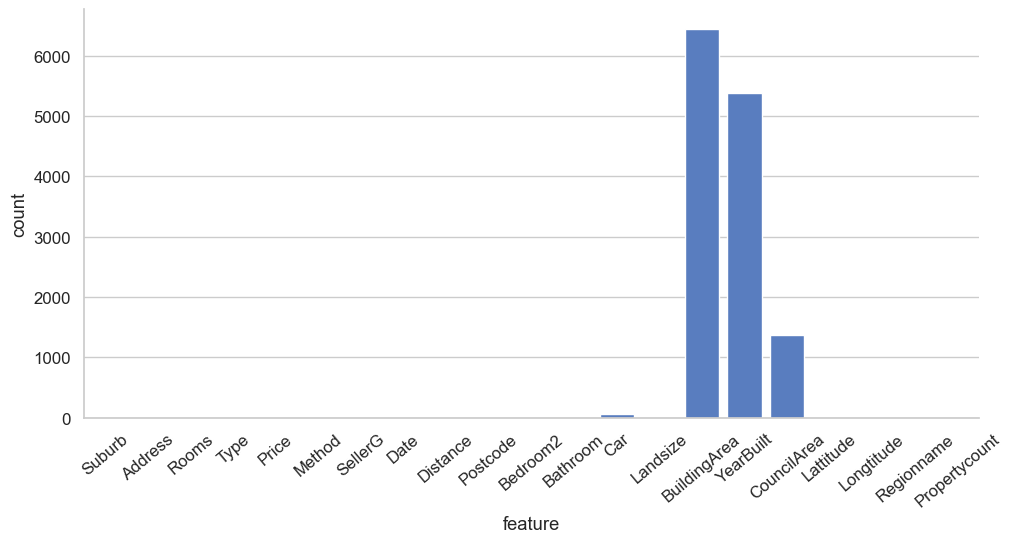

In [143]:
null_data_eda = df.select(pl.all().null_count()).transpose(include_header=True).rename({'column': 'feature', 'column_0': 'count'}) # counting null rows, transposing and writing new headers
sns.catplot(data=null_data_eda, x='feature', y='count', kind='bar', height=5,aspect=2)
plt.xticks(rotation=40); # ; to suppress the additional text

Accordingly `Bulding area`, `year built`, `car` and `council area` have null values associatied. We **won't** be touching these columns for our analysis.

Text(0.5, 0, '')

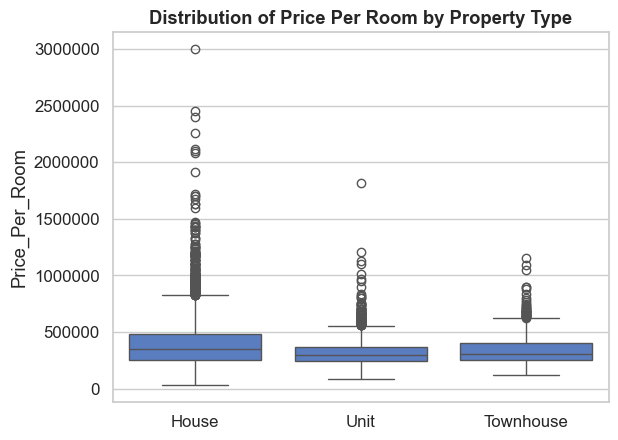

In [144]:
price_per_room = df.with_columns((pl.col("Price") / pl.col("Rooms")).alias("Price_Per_Room"))

sns.boxplot(data=price_per_room, x="Type", y="Price_Per_Room")
plt.title("Distribution of Price Per Room by Property Type", fontweight=600)
plt.ticklabel_format(style='plain', axis='y')
plt.xlabel('')

Text(0.5, 1.0, 'Top 10 Expensive Suburbs')

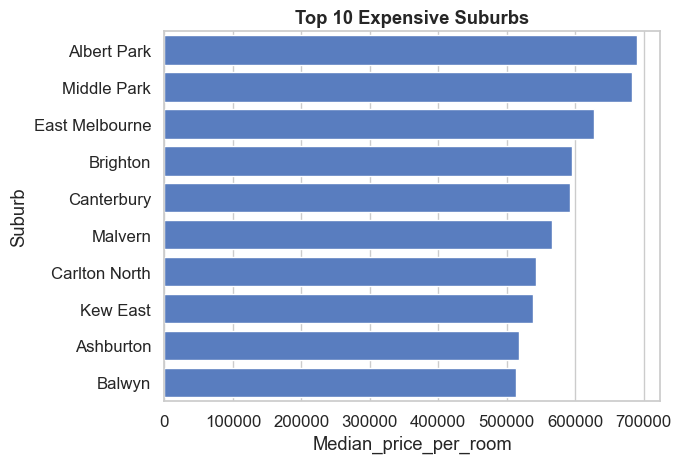

In [145]:
# Looking at top 10 most expensive suburbs per room
suburb = (price_per_room.group_by("Suburb").agg([pl.col("Price_Per_Room").median().alias("Median_price_per_room"), pl.len().alias("No.of sales")])).filter(pl.col("No.of sales") > 10).sort("Median_price_per_room", descending=True).head(10)

sns.barplot(data=suburb, x='Median_price_per_room', y='Suburb')
plt.title("Top 10 Expensive Suburbs", fontweight=600)

Text(0.5, 0, '')

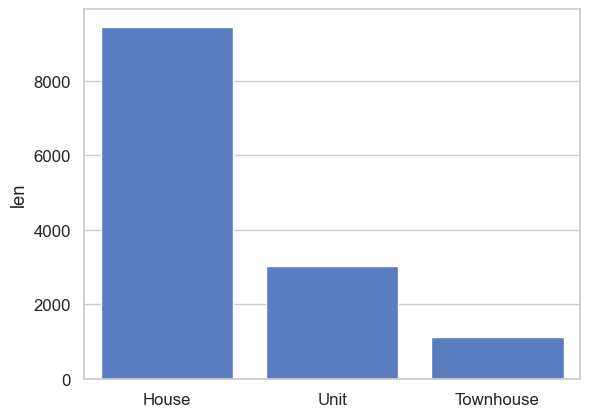

In [146]:
rtypes_eda = df.group_by('Type', maintain_order=True).len() # grouping by room types using
sns.barplot(data=rtypes_eda, x='Type', y='len')
plt.xticks([0, 1, 2], ['House', 'Unit', 'Townhouse']); # ; to suppress the additional text
plt.xlabel('')

# **Q1- What does the price trend look like?**

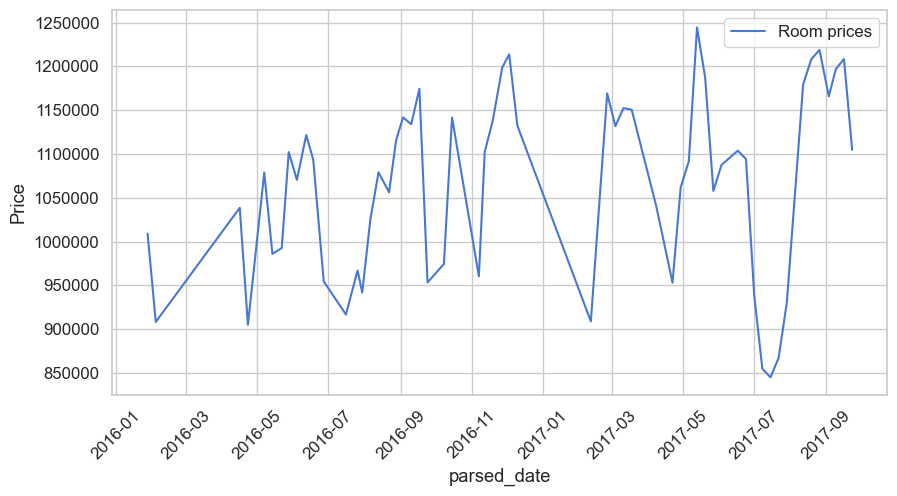

In [176]:
df = df.with_columns(pl.col("Date").str.to_date("%d/%m/%Y").alias('parsed_date'))
df = df.with_columns(pl.col('parsed_date').dt.year().alias("year"))
df = df.with_columns(pl.col('parsed_date').dt.strftime("%Y-%m").alias("year_month"))

plt.figure(figsize=(10,5))
sns.lineplot(data=df, x='parsed_date', y='Price', label='Room prices', errorbar=None)
plt.xticks(rotation=45);
plt.ticklabel_format(style='plain', axis='y')

# **Q2- Which are the cheap and expensive units?**

In [ ]:
df.sort(by='Price', descending=True)

Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
str,str,i64,str,f64,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,str,f64
"""Mulgrave""","""35 Bevis St""",3,"""House""",9e6,"""PI""","""Hall""","""29/07/2017""",18.8,3170.0,3.0,1.0,1.0,744.0,117.0,1960.0,"""Monash""",-37.93168,145.16126,"""South-Eastern Metropolitan""",7113.0
"""Canterbury""","""49 Mangarra Rd""",5,"""House""",8e6,"""VB""","""Sotheby's""","""13/05/2017""",9.0,3126.0,5.0,5.0,4.0,2079.0,464.3,1880.0,"""Boroondara""",-37.8179,145.0694,"""Southern Metropolitan""",3265.0
"""Hawthorn""","""49 Lisson Gr""",4,"""House""",7.65e6,"""S""","""Abercromby's""","""17/06/2017""",5.3,3122.0,4.0,2.0,4.0,1690.0,284.0,1863.0,"""Boroondara""",-37.82652,145.03052,"""Southern Metropolitan""",11308.0
"""Kew""","""15 Barry St""",6,"""House""",6.5e6,"""S""","""Jellis""","""13/08/2016""",5.6,3101.0,6.0,6.0,3.0,1334.0,365.0,1890.0,"""Boroondara""",-37.8029,145.0267,"""Southern Metropolitan""",10331.0
"""Middle Park""","""136 Page St""",5,"""House""",6.4e6,"""S""","""Marshall""","""9/09/2017""",3.0,3206.0,5.0,2.0,1.0,553.0,308.0,1920.0,null,-37.84908,144.95753,"""Southern Metropolitan""",2019.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""Hawthorn""","""17/17 Park St""",1,"""Unit""",160000.0,"""VB""","""HAR""","""8/04/2017""",4.6,3122.0,1.0,1.0,0.0,322.0,null,2009.0,"""Boroondara""",-37.8198,145.0373,"""Southern Metropolitan""",11308.0
"""Coburg""","""171 Moreland Rd""",4,"""House""",145000.0,"""PI""","""Jellis""","""4/06/2016""",7.8,3058.0,3.0,1.0,1.0,536.0,164.0,1910.0,"""Moreland""",-37.7555,144.9658,"""Northern Metropolitan""",11204.0
"""Albion""","""8/6 Ridley St""",1,"""Unit""",145000.0,"""PI""","""Biggin""","""28/05/2016""",13.9,3020.0,2.0,1.0,1.0,36.0,null,null,"""Brimbank""",-37.7833,144.8266,"""Western Metropolitan""",2185.0


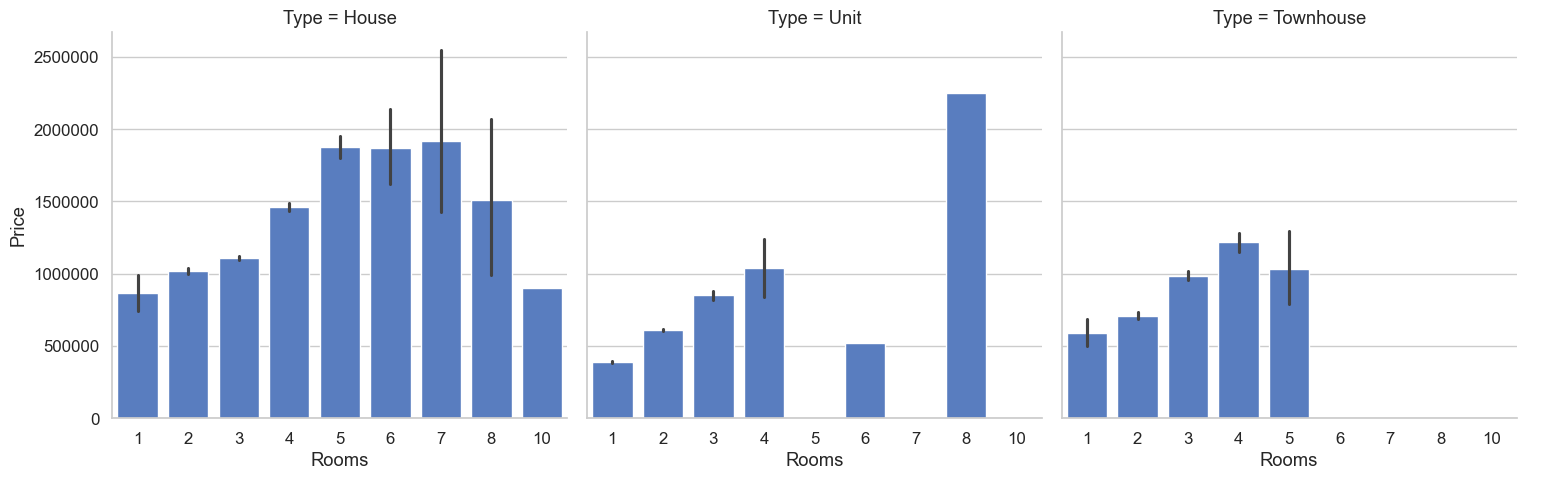

In [ ]:
price_dist = df.select("Rooms", "Type", "Price").sort(by="Price", descending=True)
sns.catplot(data=price_dist, x="Rooms", y="Price", col="Type", kind="bar")
plt.ticklabel_format(style='plain', axis='y')


An interesting thing to note in this price distribution is that as expected, the rooms get expensive until 5 rooms, after which the price starts fluctuating much as can be seen in the error bar for the plots. On a good day, one can get an 8 room house for the same price as the 4 room houses.

The unit and townhouse are also as expected, but the 8 room units are highly expensive compared to their counterparts.

Text(0, 0.5, '')

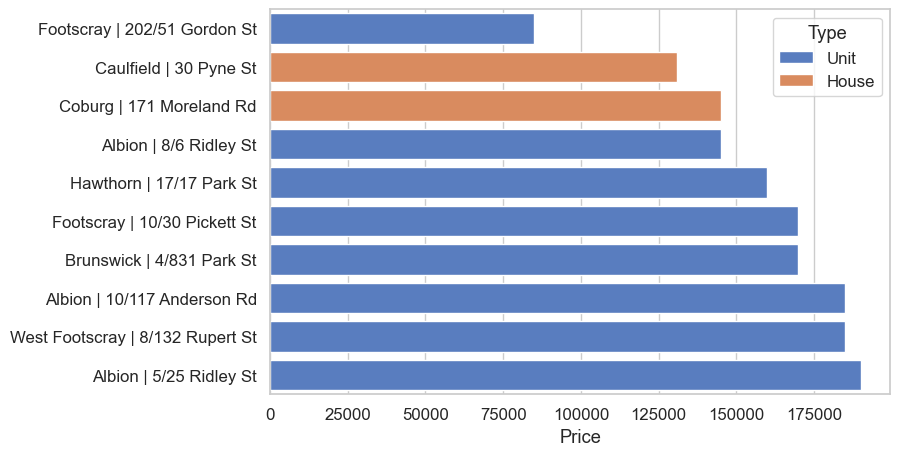

In [ ]:
# to select cheapest houses
che_h = df.select(
    pl.concat_str(["Suburb", "Address"], separator=" | ").alias("Location"), "Price", "Type"
).sort("Price").head(10) # returns top 10

plt.figure(figsize=(8,5))
sns.barplot(data=che_h, y="Location", x="Price", hue="Type", orient="h")
plt.ylabel('')


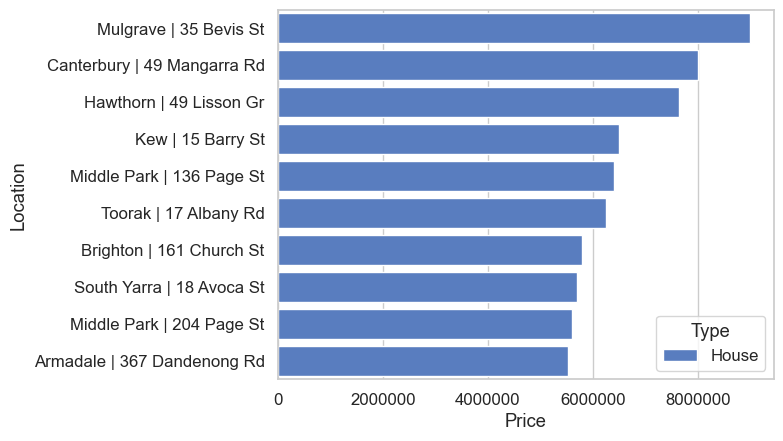

In [ ]:
# to select most expensive ones
exp_h = df.select(
    pl.concat_str(["Suburb", "Address"], separator=" | ").alias("Location"), "Price", "Type"
).sort("Price", descending=True).head(10) # returns top 10

sns.barplot(data=exp_h, y="Location", x="Price", hue="Type", orient="h")
plt.ticklabel_format(style='plain', axis='x')

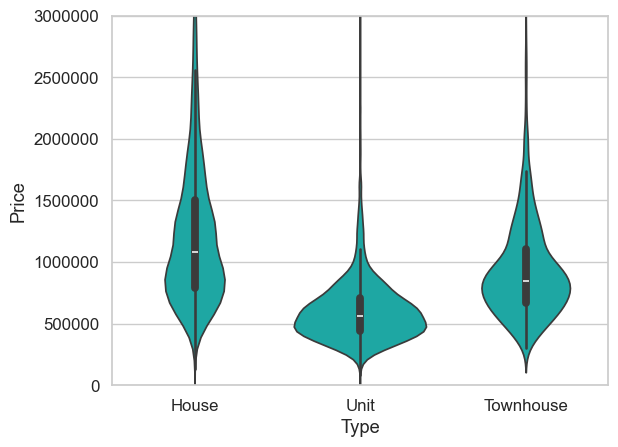

In [ ]:
# checking spread of different types
sns.violinplot(data=df, x="Type", y="Price", fill=True, color='#07BEB8')
plt.ylim(0, 3000000) # limited the y-axis to get only important part of the data
plt.ticklabel_format(style='plain', axis='y')

Majority of the houses `u` houses are distributed over the range of around **500000**, `t` being **750000** and `h` houses show wider distribution indicating `h` house prices are *very inconsistent* in places, which can be confirmed by the two graphs above the one mentioned, where `h` houses are both cheap and expensive.

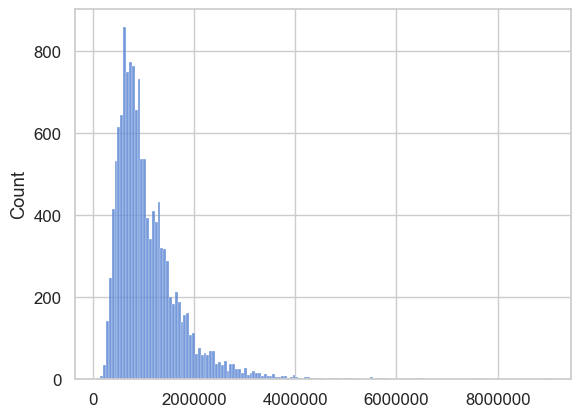

In [ ]:
sns.histplot(df['Price'])
plt.ticklabel_format(style='plain', axis='x')

This data shows distribution of the price of houses with majority of the houses lying in the 100000s.

# **Q3- Which place has the lowest price with maximum rooms**

In [ ]:
max_rooms = df.select(pl.col("Rooms").max()).item()

q2 = (
    df.filter(pl.col("Rooms") >= max_rooms)
    .select("Suburb", "Address", "Rooms", "Price", "Type")
)

print(q2)

shape: (1, 5)
┌──────────┬───────────┬───────┬──────────┬───────┐
│ Suburb   ┆ Address   ┆ Rooms ┆ Price    ┆ Type  │
│ ---      ┆ ---       ┆ ---   ┆ ---      ┆ ---   │
│ str      ┆ str       ┆ i64   ┆ f64      ┆ str   │
╞══════════╪═══════════╪═══════╪══════════╪═══════╡
│ Bundoora ┆ 5 Ball Ct ┆ 10    ┆ 900000.0 ┆ House │
└──────────┴───────────┴───────┴──────────┴───────┘


# **Q4- How distance from central distrcit affect price?**

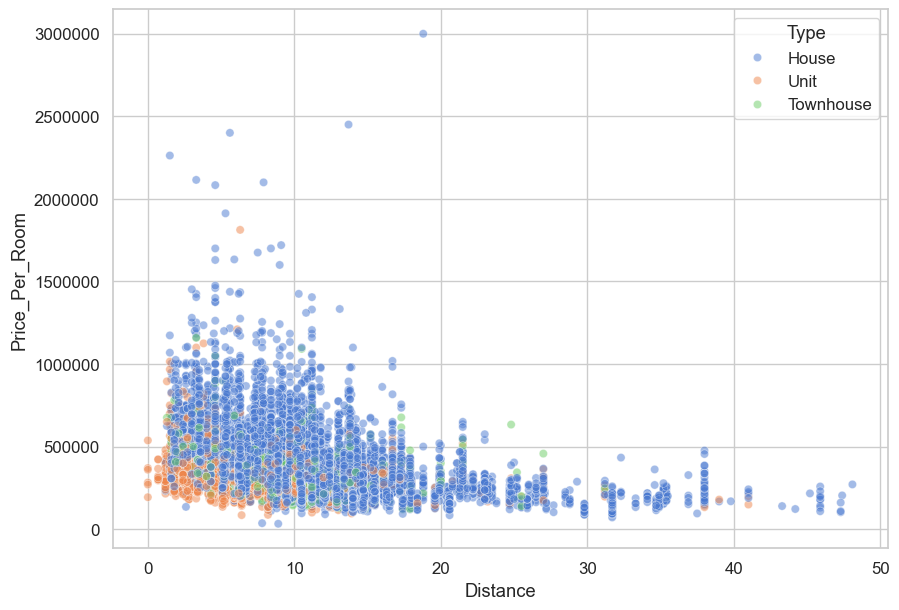

In [ ]:
plt.figure(figsize=(10,7))
sns.scatterplot(data=price_per_room, x='Distance', y='Price_Per_Room', hue='Type', alpha=0.5)
plt.ticklabel_format(style='plain', axis='y')

This clearly indicates that as you move from the city centre, the price drops drastically, and in city center, House type units are more expensive than others.